# Socioeconomic Determinants of Health Outcomes: A Data-Driven Analysis

This project explores the relationship between economic development, health outcomes, and education across countries using World Bank data.

## Introduction

This analysis investigates how GDP, life expectancy, and education are interconnected across countries.

The objective is to determine whether economic growth alone explains development, or whether health and education provide a more complete and multidimensional understanding of global progress.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import requests, zipfile, io

def load_world_bank_data(url):
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    file_name = [f for f in z.namelist() if f.startswith("API_") and "Metadata" not in f][0]
    df = pd.read_csv(z.open(file_name), skiprows=4)
    return df

In [4]:
gdp_url = "https://api.worldbank.org/v2/en/indicator/NY.GDP.MKTP.CD?downloadformat=csv"
life_url = "https://api.worldbank.org/v2/en/indicator/SP.DYN.LE00.IN?downloadformat=csv"
edu_url = "https://api.worldbank.org/v2/en/indicator/SE.ADT.LITR.ZS?downloadformat=csv"

df_gdp = load_world_bank_data(gdp_url)
df_life = load_world_bank_data(life_url)
df_edu = load_world_bank_data(edu_url)

In [5]:
def clean_df(df, value_name):
    df_clean = df.drop(columns=["Country Code", "Indicator Name", "Indicator Code"])
    
    df_clean = df_clean.melt(
        id_vars=["Country Name"],
        var_name="Year",
        value_name=value_name
    )
    
    df_clean["Year"] = pd.to_numeric(df_clean["Year"], errors="coerce")
    
    exclude_list = [
        "World",
        "Africa Eastern and Southern",
        "Africa Western and Central",
        "Sub-Saharan Africa",
        "Low income",
        "Lower middle income",
        "Upper middle income",
        "High income",
        "OECD members",
        "IDA & IBRD total",
        "IBRD only",
        "IDA total",
        "Fragile and conflict affected situations",
        "Heavily indebted poor countries (HIPC)",
        "Arab World",
        "European Union",
        "Euro area",
        "North America",
        "East Asia & Pacific",
        "Europe & Central Asia",
        "Latin America & Caribbean",
        "South Asia"
    ]
    
    df_clean = df_clean[~df_clean["Country Name"].isin(exclude_list)]
    
    return df_clean

In [6]:
df_gdp_clean = clean_df(df_gdp, "GDP")
df_life_clean = clean_df(df_life, "Life_Expectancy")
df_edu_clean = clean_df(df_edu, "Education")

In [7]:
df_final = df_gdp_clean.merge(df_life_clean, on=["Country Name", "Year"], how="inner")
df_final = df_final.merge(df_edu_clean, on=["Country Name", "Year"], how="inner")

df_final.head()

,Country Name,Year,GDP,Life_Expectancy,Education
0,Aruba,1960.0,NaN,64.049,NaN
1,Afghanistan,1960.0,NaN,32.799,NaN
2,Angola,1960.0,NaN,37.933,NaN
3,Albania,1960.0,NaN,56.413,NaN
4,Andorra,1960.0,NaN,72.094,NaN


In [8]:
df_final[["GDP", "Life_Expectancy", "Education"]].corr()

,GDP,Life_Expectancy,Education
GDP,1.000000,0.144055,0.150304
Life_Expectancy,0.144055,1.000000,0.821508
Education,0.150304,0.821508,1.000000


In [9]:
df_final.columns

Index(['Country Name', 'Year', 'GDP', 'Life_Expectancy', 'Education'], dtype='object')

In [10]:
df_final.head()

,Country Name,Year,GDP,Life_Expectancy,Education
0,Aruba,1960.0,NaN,64.049,NaN
1,Afghanistan,1960.0,NaN,32.799,NaN
2,Angola,1960.0,NaN,37.933,NaN
3,Albania,1960.0,NaN,56.413,NaN
4,Andorra,1960.0,NaN,72.094,NaN


In [11]:
df_final.isnull().sum()

Country Name           0
Year                 244
GDP                 3209
Life_Expectancy      587
Education          14273
dtype: int64

In [12]:
df_final.columns.tolist()

['Country Name', 'Year', 'GDP', 'Life_Expectancy', 'Education']

In [13]:
df_final = df_final.rename(columns={
    "Life_Expectancy": "life_expectancy",
    "GDP": "gdp",
    "Education": "education"
})

In [14]:
print(df_final.columns.tolist())

['Country Name', 'Year', 'gdp', 'life_expectancy', 'education']


In [15]:
for col in df_final.columns:
    print(f"'{col}'")

'Country Name'
'Year'
'gdp'
'life_expectancy'
'education'


In [16]:
df_final.head()

,Country Name,Year,gdp,life_expectancy,education
0,Aruba,1960.0,NaN,64.049,NaN
1,Afghanistan,1960.0,NaN,32.799,NaN
2,Angola,1960.0,NaN,37.933,NaN
3,Albania,1960.0,NaN,56.413,NaN
4,Andorra,1960.0,NaN,72.094,NaN


In [17]:
import os
os.listdir()

['.anaconda',
 '.conda',
 '.continuum',
 '.copilot',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.virtual_documents',
 '.vscode',
 'anaconda3',
 'ansel',
 'Antimicrobial Resistance Dataset.zip',
 'Antimicrobial Resistance Genomic Analysis & Predictive Modelling.ipynb',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'data',
 'diabetic_data.zip',
 'Documents',
 'Downloads',
 'Favorites',
 'Hospital Readmission Prediction.ipynb',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{89aaaaa7-a48b-11f0-9fdc-f44eb4e0b2e2}.TM.blf',
 'NTUSER.DAT{89aaaaa7-a48b-11f0-9fdc-f44eb4e0b2e2}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{89aaaaa7-a48b-11f0-9fdc-f44eb4e0b2e2}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pictures',
 'PrintHood',
 'P_Data_Extract_From_World_Development_Indicators.zip',
 'Recent',
 'Saved Games',
 'S

In [18]:
import os
os.makedirs("visualizations", exist_ok=True)

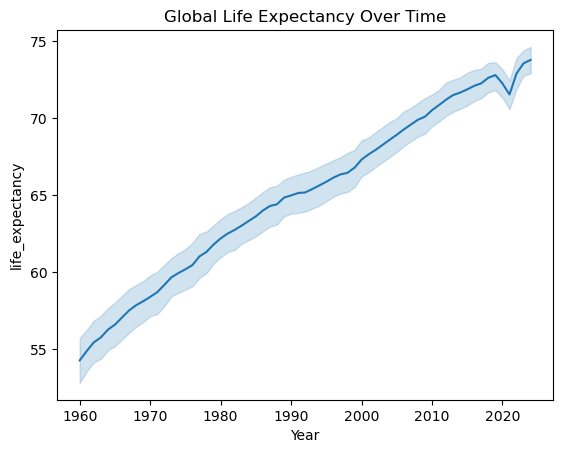

In [19]:
plt.figure()

sns.lineplot(
    data=df_final,
    x="Year",
    y="life_expectancy"
)

plt.title("Global Life Expectancy Over Time")

plt.savefig("visualizations/life_expectancy_trend.png", dpi=300, bbox_inches='tight')

plt.show()

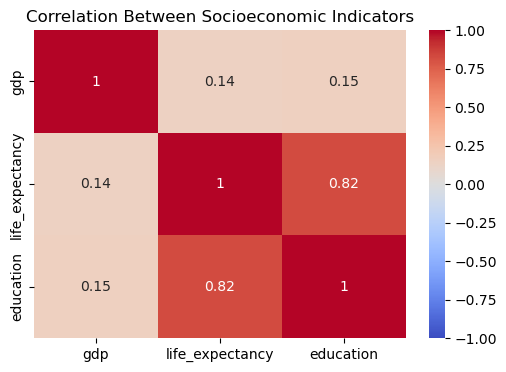

In [20]:
plt.figure(figsize=(6,4))

sns.heatmap(df_final[["gdp","life_expectancy","education"]].corr(),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation Between Socioeconomic Indicators")

plt.savefig("visualizations/correlation_socioeconimic_indicators.png", dpi=300, bbox_inches="tight")

plt.show()

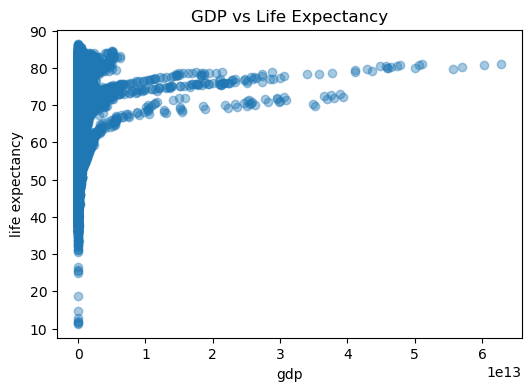

In [21]:
plt.figure(figsize=(6,4))
plt.scatter(df_final["gdp"], df_final["life_expectancy"], alpha=0.4)
plt.xlabel("gdp")
plt.ylabel("life expectancy")
plt.title("GDP vs Life Expectancy")
plt.savefig("visualizations/gdp_vs_life_expectancy.png", dpi=300, bbox_inches="tight")
plt.show()

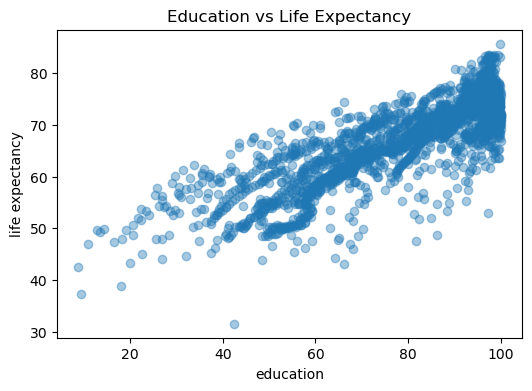

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(df_final["education"], df_final["life_expectancy"], alpha=0.4)
plt.xlabel("education")
plt.ylabel("life expectancy")
plt.title("Education vs Life Expectancy")
plt.savefig("visualizations/education_vs_life_expectancy.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Insights

- GDP is positively associated with life expectancy, but the relationship varies across countries.
- Education shows a strong and consistent relationship with life expectancy.
- Development is multidimensional and cannot be explained by economic output alone.
- Health, education, and economic indicators reinforce each other in shaping development outcomes.

## 📊 Predictive Modeling: Relationship Between Education and Life Expectancy

This section applies a simple linear regression model to examine whether education levels can help explain variations in life expectancy across countries. The goal is to build an interpretable baseline model rather than a complex machine learning system, focusing on real-world relationships between human development indicators.

In [26]:
df_model = df_final[["education", "life_expectancy"]].dropna()

X = df_model[["education"]]
y = df_model["life_expectancy"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 3.538274222379698
R2 Score: 0.6331498403365923


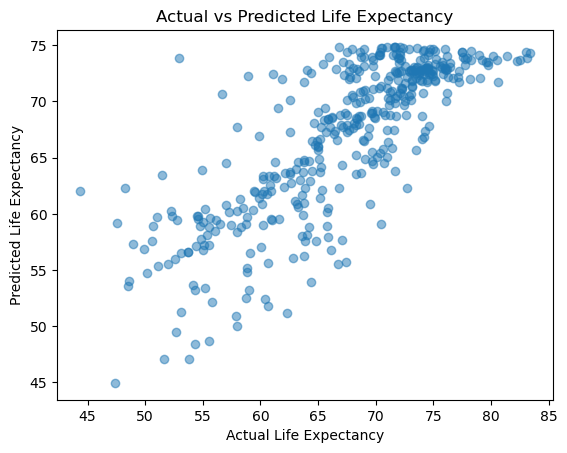

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy")
plt.savefig("visualizations/actual_vs_predicted_life_expectancy.png", dpi=300, bbox_inches="tight")
plt.show()

## 🤖 Classification Model: High vs Low Life Expectancy

To extend the analysis beyond regression, this section reframes life expectancy as a binary classification problem. Countries are categorized into high and low life expectancy groups based on the median value.

This allows us to apply a classification algorithm to explore whether education levels can help distinguish between higher and lower health outcome groups.

In [35]:
df_cls = df_final[["education", "life_expectancy"]].copy()

# remove missing values FIRST
df_cls = df_cls.dropna()

In [36]:
import numpy as np

threshold = df_cls["life_expectancy"].median()

df_cls["high_life_expectancy"] = np.where(
    df_cls["life_expectancy"] >= threshold, 1, 0
)

In [37]:
X = df_cls[["education"]]
y = df_cls["high_life_expectancy"]

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred = clf.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8313253012048193
              precision    recall  f1-score   support

           0       0.86      0.79      0.82       208
           1       0.81      0.87      0.84       207

    accuracy                           0.83       415
   macro avg       0.83      0.83      0.83       415
weighted avg       0.83      0.83      0.83       415



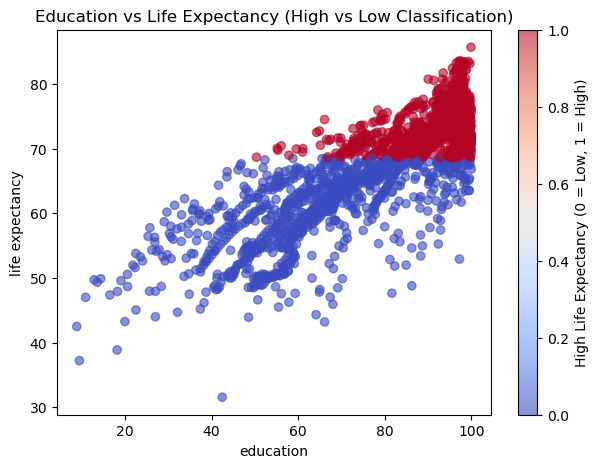

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Scatter plot of actual data
plt.scatter(
    df_cls["education"],
    df_cls["life_expectancy"],
    c=df_cls["high_life_expectancy"],
    cmap="coolwarm",
    alpha=0.6
)

plt.xlabel("education")
plt.ylabel("life expectancy")
plt.title("Education vs Life Expectancy (High vs Low Classification)")

plt.savefig("visualizations/education_vs_life_expectancy.png", dpi=300, bbox_inches="tight")

cbar = plt.colorbar()
cbar.set_label("High Life Expectancy (0 = Low, 1 = High)")

plt.show()

In [44]:
print(type(model))
print(X_test.shape)
print(y_pred[:5])

<class 'sklearn.linear_model._base.LinearRegression'>
(415, 1)
[0 0 1 1 1]


## 🔍 Key Findings

- Education shows a positive relationship with life expectancy across countries, suggesting that higher education levels are associated with better health outcomes.

- The classification model indicates that education alone provides meaningful signal in distinguishing between high and low life expectancy groups, although it is not the sole determining factor.

- The relationship between socioeconomic development and health outcomes appears to be interdependent rather than linear or isolated.

- Simpler models (linear regression and logistic regression) are sufficient to reveal meaningful global patterns in development indicators.

## 🧾 Conclusion

This analysis demonstrates that life expectancy is closely connected to broader socioeconomic factors, particularly education. While economic indicators and education levels provide useful explanatory power, they do not operate in isolation.

Using both regression and classification approaches, this project highlights how data science can be used to uncover meaningful relationships in global development data.

Rather than focusing on complex modeling, this project emphasizes interpretability, data quality, and real-world relevance—showing how even simple machine learning techniques can provide valuable insights into public health and development patterns.

Overall, this project reflects an applied approach to data science that bridges health, education, and socioeconomic analysis.